In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("..")
print("at directory:", os.getcwd())

at directory: /n/home13/wcarvalho/projects/preplay-human/analysis_notebooks
changing to root directory
at directory: /n/home13/wcarvalho/projects/preplay-human


In [3]:
sys.path.append("simulations")

In [4]:
# from analysis import craftax_model_data
import ipywidgets
from tqdm.notebook import tqdm
from IPython.display import display

from analysis import craftax_user_data
from analysis import craftax_analysis
import nicewebrl
import polars as pl


%matplotlib inline

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Loading Craftax textures from cache.
Textures successfully loaded from cache.
Loading textures from cache.
Textures successfully loaded from cache.


/n/home13/wcarvalho/projects/preplay-human/analysis/craftax_user_data.py:36: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


# Simulation data

In [20]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"

################
# Load model data
################
# %debug
model_df = housemaze_model_data.get_model_data(
  qlearning_path=f"{data_dir}/model_data/ql/save_data/ql-big-2/tota=40000000,exp=exp2/seed=*",
  sf_path=f"{data_dir}/model_data/usfa/save_data/usfa-big-10-search/sf_h=1024,num_=2,tota=40000000,exp=exp2/seed=*",
  dyna_path=f"{data_dir}/model_data/dynaq_shared/save_data/dynaq-big-4/alg=dynaq_shared,agen=256,tota=100000000,exp=exp2/seed=*",
  search_path=f"{data_dir}/search_algos",
  overwrite_episodes=False,
  overwrite_df=False,
)

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
Error loading cached model data: No module named 'simulations.offtask_dyna'


  0%|          | 0/5 [00:00<?, ?it/s]

No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
qlearning: Loading from /Users/wilka/git/research/results/human_dyna//model_data/ql/save_data/ql-big-2/tota=40000000,exp=exp2/seed=1/analysis//qlearning_timesteps.pickle
qlearning: Loaded 300 episodes
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
qlearning: Loading from /Users/wilka/git/research/results/human_dyna//model_data/ql/save_data/ql-big-2/tota=40000000,exp=exp2/seed=2/analysis//qlearning_timesteps.pickle
qlearning: Loaded 300 episodes
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
qlearning: Loading from /Users/wilka/git/research/results/human_dyna//model_data/ql/save_data/ql-big-2/tota=40000000,exp=exp2/seed=5/analysis//qlearning_timesteps.pickle
qlearning: Loa

  0%|          | 0/1 [00:00<?, ?it/s]

No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
usfa: Loading from /Users/wilka/git/research/results/human_dyna//model_data/usfa/save_data/usfa-big-10-search/sf_h=1024,num_=2,tota=40000000,exp=exp2/seed=1/analysis//usfa_timesteps.pickle
usfa: Loaded 12 episodes


...

No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
dynaq_shared: Loading from /Users/wilka/git/research/results/human_dyna//model_data/dynaq_shared/save_data/dynaq-big-4/alg=dynaq_shared,agen=256,tota=100000000,exp=exp2/seed=1/analysis//dynaq_shared_timesteps.pickle
dynaq_shared: Loaded 300 episodes
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
dynaq_shared: Loading from /Users/wilka/git/research/results/human_dyna//model_data/dynaq_shared/save_data/dynaq-big-4/alg=dynaq_shared,agen=256,tota=100000000,exp=exp2/seed=2/analysis//dynaq_shared_timesteps.pickle
dynaq_shared: Loaded 300 episodes
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
bfs: Loading from /Users/wilka/git/research/results/human_dyna//search_algos/analysis/

bfs: planning:   0%|          | 0/100 [00:00<?, ?it/s]

bfs: Loaded 1200 episodes
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
dfs: Loading from /Users/wilka/git/research/results/human_dyna//search_algos/analysis//dfs_timesteps.pickle


dfs: planning:   0%|          | 0/100 [00:00<?, ?it/s]

dfs: Loaded 1200 episodes
Cached model data to /Users/wilka/git/research/results/human_dyna//model_data/ql/save_data/ql-big-2/tota=40000000,exp=exp2/model_data_cache_episodes.pickle


In [5]:
# model_df = model_df.rename({'went_to_junction': 'reuse'})

# Human data

In [5]:
# ON SERVER
RESULTS_DIR ='/n/holylfs06/LABS/kempner_fellow_wcarvalho'
USER_RESULTS_DIR = os.path.join(RESULTS_DIR, 'results/human_dyna_craftax/user_data/exps')

In [6]:
# # ON COMPUTER
# RESULTS_DIR ='/Users/wilka/git/research/'
# USER_RESULTS_DIR = os.path.join(RESULTS_DIR, 'results/human_dyna_craftax/user_data/exps')

In [7]:
from glob import glob

files = f"{USER_RESULTS_DIR}/*v3*.json"
files = list(set(glob(files)))
len(files)

43

In [8]:
import craftax_experiment_structure as experiment
import asyncio

# %debug
user_df = await craftax_user_data.get_human_data(
    files,
    overwrite_episode_data=False,
    overwrite_episode_info=False,
    debug=False,
)

Compiling environment reset and step functions.
	reset time: 23.20382523536682
	step time: 28.522550582885742
Compiling multi-render function.
	time: 5.278558254241943
0/43 /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=2998019967_worker=A3QNCW3LR2AVOV_name=craftax_v3-paths-r0-m0_debug=0.json
skipping /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=2998019967_worker=A3QNCW3LR2AVOV_name=craftax_v3-paths-r0-m0_debug=0.json because one of the episode_df or episode_data is None
Loaded episode data from /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps//user=1382413084_worker=A34930YXVQ8SUT_name=craftax_v3-paths-r1-m0_debug=0_episode_data.bytes


Failed to unpack record in /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=1641903520_worker=A3BUPP17GN7I1H_name=craftax_v3-paths-r0-m0_debug=0.json: unpack(b) received extra data.


Loaded episode info from /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps//user=1382413084_worker=A34930YXVQ8SUT_name=craftax_v3-paths-r1-m0_debug=0_episode_info.csv
1/43 /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=1382413084_worker=A34930YXVQ8SUT_name=craftax_v3-paths-r1-m0_debug=0.json
2/43 /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=1641903520_worker=A3BUPP17GN7I1H_name=craftax_v3-paths-r0-m0_debug=0.json
skipping /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=1641903520_worker=A3BUPP17GN7I1H_name=craftax_v3-paths-r0-m0_debug=0.json because one of the episode_df or episode_data is None
Loaded episode data from /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps//user=2230958349_worker=A3BSK47WPPE876_name=craftax_v3-paths-r1-m0_debug=0_episode_data.bytes
Loaded episode info from /n/h

A* Iterations: 0it [00:00, ?it/s]

A* Iterations: 0it [00:00, ?it/s]

...

30/43 /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=311884650_worker=A3BUPP17GN7I1H_name=craftax_v3-paths-r1-m0_debug=0.json
skipping /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=311884650_worker=A3BUPP17GN7I1H_name=craftax_v3-paths-r1-m0_debug=0.json because one of the episode_df or episode_data is None
Loaded episode data from /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps//user=4233642709_worker=A2FHM2F9QKP0O0_name=craftax_v3-paths-r0-m0_debug=0_episode_data.bytes
Loaded episode info from /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps//user=4233642709_worker=A2FHM2F9QKP0O0_name=craftax_v3-paths-r0-m0_debug=0_episode_info.csv
31/43 /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=4233642709_worker=A2FHM2F9QKP0O0_name=craftax_v3-paths-r0-m0_debug=0.json
Loaded episode data from /n/h

Failed to unpack record in /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=1207509733_worker=A1F6MWP9A0XLJQ_name=craftax_v3-paths-r1-m0_debug=0.json: unpack(b) received extra data.


34/43 /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=1207509733_worker=A1F6MWP9A0XLJQ_name=craftax_v3-paths-r1-m0_debug=0.json
skipping /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=1207509733_worker=A1F6MWP9A0XLJQ_name=craftax_v3-paths-r1-m0_debug=0.json because one of the episode_df or episode_data is None
Loaded episode data from /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps//user=213640548_worker=A2FHM2F9QKP0O0_name=craftax_v3-paths-r1-m0_debug=0_episode_data.bytes
Loaded episode info from /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps//user=213640548_worker=A2FHM2F9QKP0O0_name=craftax_v3-paths-r1-m0_debug=0_episode_info.csv
35/43 /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=213640548_worker=A2FHM2F9QKP0O0_name=craftax_v3-paths-r1-m0_debug=0.json
Loaded episode data from /n/ho

Failed to unpack record in /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=957564031_worker=AJQ71YIGY01HZ_name=craftax_v3-paths-r0-m0_debug=0.json: unpack(b) received extra data.


Loaded episode data from /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps//user=2617232665_worker=A2SKY4RRWII0BF_name=craftax_v3-paths-r0-m0_debug=0_episode_data.bytes
Loaded episode info from /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps//user=2617232665_worker=A2SKY4RRWII0BF_name=craftax_v3-paths-r0-m0_debug=0_episode_info.csv
39/43 /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=2617232665_worker=A2SKY4RRWII0BF_name=craftax_v3-paths-r0-m0_debug=0.json
40/43 /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=957564031_worker=AJQ71YIGY01HZ_name=craftax_v3-paths-r0-m0_debug=0.json
skipping /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=957564031_worker=AJQ71YIGY01HZ_name=craftax_v3-paths-r0-m0_debug=0.json because one of the episode_df or episode_data is None
Loaded episode data from /n/hol

In [37]:
new = user_df.filter(eval=True)['overlap']
new.plot.hist()

ModuleUpgradeRequiredError: altair>=5.4.0 is required for `.plot`

# Analysis

## Path reuse

In [14]:
eval_map = 0
tell_reuse = 0

In [15]:
import polars as pl
sub_df = user_df.filter_by_group(
    input_episode_filter=craftax_analysis.filter_train_by_min_success,
    input_settings=dict(eval=False),
    output_settings=dict(manipulation='paths', tell_reuse=tell_reuse, eval_map=eval_map),
    group_key="user_id",
  ).filter(eval=True)
# Convert reuse column from string to boolean
if sub_df.schema["reuse"] == pl.String:
    sub_df = sub_df.with_columns(pl.col("reuse") == "true")
elif sub_df.schema["reuse"] == pl.Boolean:
    pass
else:
    raise ValueError("Reuse column is type: ", exp1_eval_df.schema["reuse"])
len(sub_df)

61

In [27]:
# # TODO: delete later
# df = sub_df
# human_reuse = (
#     df.group_by("user_id")
#     .agg(pl.col("reuse").mean())
#     .select(["user_id", "reuse"])
# )

# Print user_id: reuse pairs
for row in sub_df.iter_rows(named=True):
    print(f"User {row['user_id']}: {row['reuse']}")


User 10434196: True
User 10434196: True
User 10434196: True
User 10434196: False
User 122928105: True
User 122928105: True
User 122928105: True
User 122928105: None
User 818906834: False
User 818906834: True
User 818906834: True
User 818906834: True
User 2349435691: True
User 2349435691: False
User 2349435691: False
User 2349435691: True
User 2540827707: False
User 2540827707: True
User 2540827707: True
User 2540827707: True
User 2617232665: True
User 2617232665: True
User 2617232665: False
User 2617232665: True
User 2635592883: None
User 2635592883: False
User 2635592883: True
User 2635592883: True
User 2836227078: True
User 2836227078: True
User 2836227078: True
User 2836227078: True
User 2951292398: True
User 2951292398: True
User 2951292398: None
User 2951292398: True
User 3150828290: True
User 3150828290: True
User 3150828290: True
User 3150828290: True
User 3385462005: True
User 3385462005: True
User 3385462005: True
User 3385462005: True
User 3638567733: False
User 3638567733: T

{'success': 97.77777777777777, 'reuse': 78.88888888888889, 'success_se': 3.8059948381230035, 'reuse_se': 10.537020764161099}


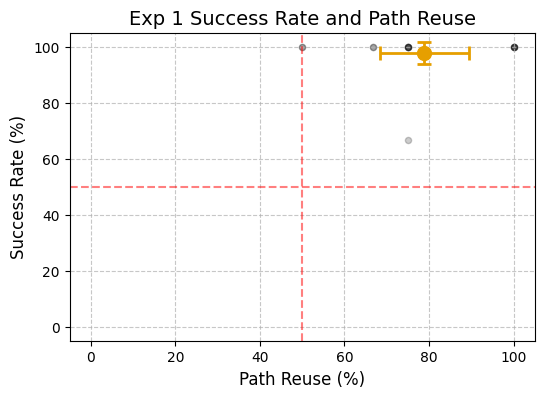

In [28]:
fig, ax = craftax_analysis.plot_success_rate_path_reuse_metrics(
    df=sub_df,
    model_df=None,
    title="Exp 1 Success Rate and Path Reuse",
    figsize=(6, 4),
    include_raw_data=True,
)

Filtered 9 rows with null success or reuse
Filtered 9 rows with null success or reuse


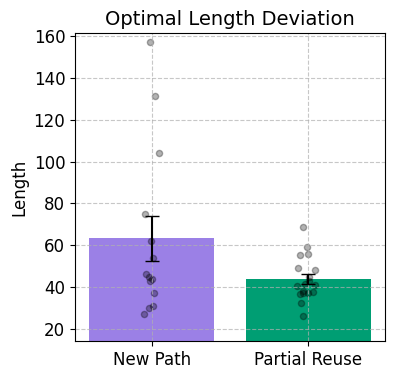

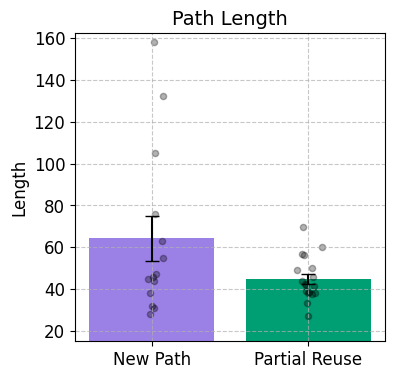

In [38]:
for measure in [
    # 'log_first_rt',
    'optimal_length_deviance',
    'path_length']:
    fig, ax = plt.subplots(figsize=(4, 4))
    idx = 0
    craftax_analysis.plot_bar_rt_comparison(
      sub_df,
      measure,
      title=dict(
        log_first_rt="First Reaction Time",
        log_avg_rt="Average Reaction Time",
        log_max_rt="Max Reaction Time",
        optimal_length_deviance="Optimal Length Deviation",
        path_length="Path Length",
      )[measure],
      ylabel="log seconds" if 'rt' in measure else "Length",
      xlabels=["New Path", "Partial Reuse"],
      colors=[craftax_analysis.default_colors["nice purple"], craftax_analysis.default_colors["bluish green"]],
      n_simulations=1,
      ax=ax,
    )


{'success': 97.77777777777777, 'reuse': 78.88888888888889, 'success_se': 3.8059948381230035, 'reuse_se': 10.537020764161099}


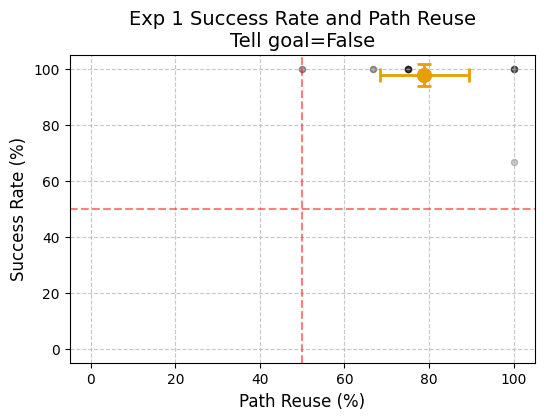

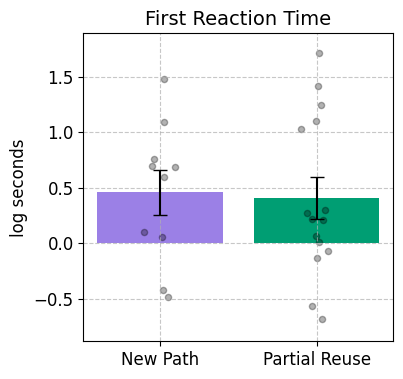

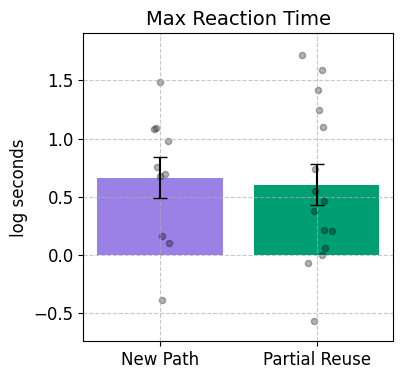

{'success': 92.12962962962963, 'reuse': 72.22222222222221, 'success_se': 6.3468903465058, 'reuse_se': 10.557179862029056}


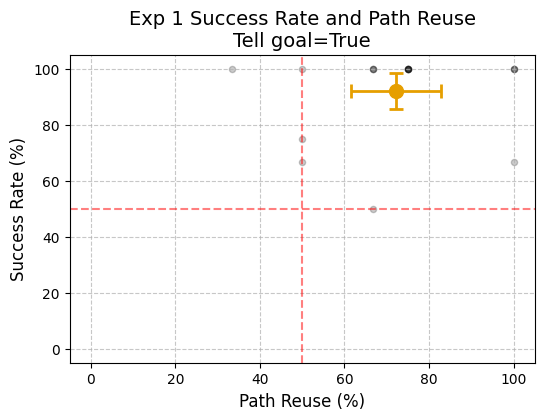

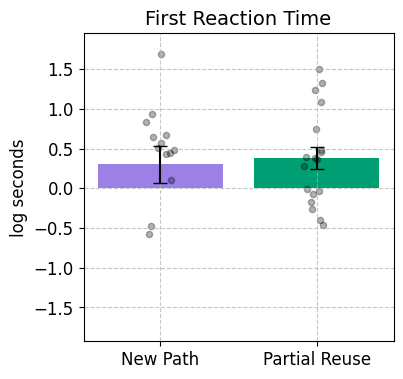

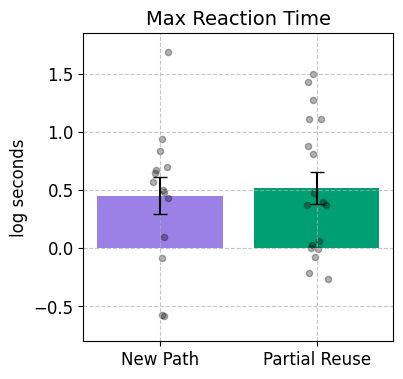

In [29]:
# for eval_map in [0, 1]:
import matplotlib.pyplot as plt
eval_map=0
for tell_reuse in [0, 1]:
    sub_df = user_df.filter_by_group(
        input_episode_filter=craftax_analysis.filter_train_by_min_success,
        input_settings=dict(eval=False),
        output_settings=dict(manipulation='paths', tell_reuse=tell_reuse, eval_map=eval_map),
        group_key="user_id",
      ).filter(eval=True)
    # Convert reuse column from string to boolean
    if sub_df.schema["reuse"] == pl.String:
        sub_df = sub_df.with_columns(pl.col("reuse") == "true")
    elif sub_df.schema["reuse"] == pl.Boolean:
        pass
    else:
        raise ValueError("Reuse column is type: ", exp1_eval_df.schema["reuse"])
    fig, ax = craftax_analysis.plot_success_rate_path_reuse_metrics(
        df=sub_df,
        model_df=None,
        title=f"Exp 1 Success Rate and Path Reuse\nTell goal={bool(tell_reuse)}",
        figsize=(6, 4),
        include_raw_data=True,
    )
    plt.show()
    fig, ax = plt.subplots(figsize=(4, 4))
    idx = 0
    measure = "log_first_rt"
    craftax_analysis.plot_bar_rt_comparison(
      sub_df,
      measure,
      title=dict(
        log_first_rt="First Reaction Time",
        log_avg_rt="Average Reaction Time",
        log_max_rt="Max Reaction Time",
      )[measure],
      ylabel="log seconds",
      xlabels=["New Path", "Partial Reuse"],
      colors=[craftax_analysis.default_colors["nice purple"], craftax_analysis.default_colors["bluish green"]],
      n_simulations=1,
      ax=ax,
    )
    plt.show()
    fig, ax = plt.subplots(figsize=(4, 4))
    idx = 0
    measure = "log_max_rt"
    craftax_analysis.plot_bar_rt_comparison(
      sub_df,
      measure,
      title=dict(
        log_first_rt="First Reaction Time",
        log_avg_rt="Average Reaction Time",
        log_max_rt="Max Reaction Time",
      )[measure],
      ylabel="log seconds",
      xlabels=["New Path", "Partial Reuse"],
      colors=[craftax_analysis.default_colors["nice purple"], craftax_analysis.default_colors["bluish green"]],
      n_simulations=1,
      ax=ax,
    )
    plt.show()

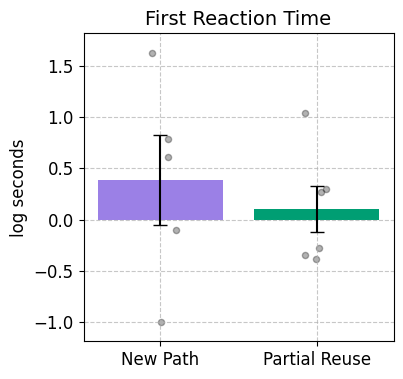

In [26]:
measure='log_first_rt'
    fig, ax = plt.subplots(figsize=(4, 4))
    idx = 0
    measure = "log_first_rt"
    craftax_analysis.plot_bar_rt_comparison(
      sub_df,
      measure,
      title=dict(
        log_first_rt="First Reaction Time",
        log_avg_rt="Average Reaction Time",
        log_max_rt="Max Reaction Time",
      )[measure],
      ylabel="log seconds",
      xlabels=["New Path", "Partial Reuse"],
      colors=[craftax_analysis.default_colors["nice purple"], craftax_analysis.default_colors["bluish green"]],
      n_simulations=1,
      ax=ax,
    )


## Juncture?

In [29]:
import polars as pl
import functools

eval_map=0
tell_reuse=0
sub_df = user_df.filter(manipulation='juncture', tell_reuse=tell_reuse, eval_map=eval_map)._df
# sub_df = sub_df.with_columns(
#     pl.col("name").str.extract(r"([^_]+_\d+)").alias("block_name")
#   )
len(sub_df)

200

In [30]:
sub_df

index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,success,path_length,termination,log_first_rt,log_avg_rt,log_total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance,reuse,overlap
u32,i64,i64,str,str,str,i64,i64,bool,i64,i64,str,i64,i64,str,str,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,str,str
0,2,0,"""juncture_1_training""","""probe behavior at juncture""","""juncture""",0,1,false,22,0,"""[17 34]""",3480725920,38,"""Female""","""craftax_v1-juncture-r0-m0""",0,0,0,1,1,1.0,30,1.0,2.2321637,-0.921321,-27.63963,-1.030062,2.2321637,0.23587,-0.352384,0.23587,0.23587,29,null,null
1,2,0,"""juncture_1_training""","""probe behavior at juncture""","""juncture""",1,2,false,22,0,"""[ 6 35]""",3480725920,38,"""Female""","""craftax_v1-juncture-r0-m0""",0,0,0,1,1,1.0,53,1.0,1.2748069,-0.882356,-46.76486,-0.92384,1.2748069,0.7537765,0.7537765,-0.098705,-0.098705,52,null,null
2,2,0,"""juncture_1_training""","""probe behavior at juncture""","""juncture""",2,3,false,22,0,"""[17 34]""",3480725920,38,"""Female""","""craftax_v1-juncture-r0-m0""",0,0,0,1,1,1.0,27,1.0,1.2406933,-1.03853,-28.040306,-1.126192,1.2406933,0.044983,-0.309233,0.044983,0.044983,26,null,null
3,2,0,"""juncture_1_training""","""probe behavior at juncture""","""juncture""",3,4,false,22,0,"""[23 18]""",3480725920,38,"""Female""","""craftax_v1-juncture-r0-m0""",0,0,0,1,1,1.0,40,1.0,1.6308099,-0.799054,-31.962154,-0.861358,1.6308099,0.23508,0.15872,0.23508,0.23508,39,null,null
4,2,0,"""juncture_1_training""","""probe behavior at juncture""","""juncture""",4,5,false,22,0,"""[23 18]""",3480725920,38,"""Female""","""craftax_v1-juncture-r0-m0""",0,0,0,1,1,1.0,27,1.0,1.1088959,-0.742935,-20.059233,-0.814159,1.1088959,0.7682592,0.340756,0.7682592,0.7682592,26,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
195,16,0,"""juncture_2_training""","""probe behavior at juncture""","""juncture""",35,6,false,10,0,"""[25 33]""",2085357097,28,"""Male""","""craftax_v1-juncture-r0-m0""",0,0,0,1,1,1.0,24,1.0,-0.440041,-1.518065,-36.433556,-1.564935,-0.440041,-1.064182,-1.21399,-1.064182,-1.064182,23,null,null
196,16,0,"""juncture_2_training""","""probe behavior at juncture""","""juncture""",36,7,false,10,0,"""[25 33]""",2085357097,28,"""Male""","""craftax_v1-juncture-r0-m0""",0,0,0,1,1,1.0,24,1.0,-0.228144,-1.32799,-31.87175,-1.375809,1.0946076,1.0946076,1.0946076,-0.011051,1.0946076,23,null,null
197,16,0,"""juncture_2_training""","""probe behavior at juncture""","""juncture""",37,8,false,10,0,"""[15 26]""",2085357097,28,"""Male""","""craftax_v1-juncture-r0-m0""",0,0,0,1,1,1.0,6,1.0,0.366038,-0.936149,-5.616896,-1.196587,0.366038,-0.592379,-0.592379,0.366038,-1.016083,5,null,null


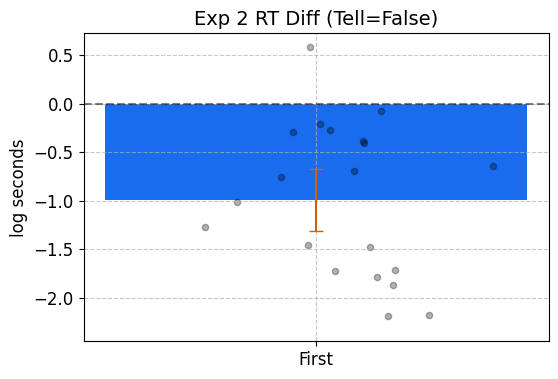

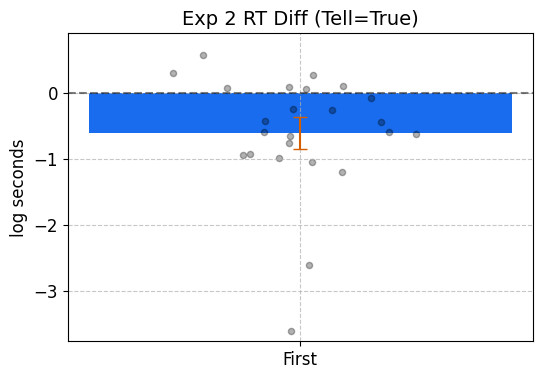

In [31]:
from typing import List

def compute_condition_difference_df(
  df: pl.DataFrame, measures: List[str]
) -> pl.DataFrame:
  """Compute differences between conditions 1 and 2 for matched reversal conditions.

  Args:
      df: DataFrame containing columns [condition, reversal, setting, {measures}]
      setting: Which setting to filter for ('short' or 'long')
      measures: List of measure column names to compute differences for

  Returns:
      DataFrame with columns [user_id, reversal, diff_{measure1}, diff_{measure2}, ...]
  """

  # Get condition 1 and 2 data separately
  cond1_df = df.filter(condition=1)
  cond2_df = df.filter(condition=2)

  # Join the dataframes on user_id and reversal to match pairs
  diff_df = cond1_df.join(cond2_df, on=["user_id", "block_name"], suffix="_cond2")

  # Compute differences for each measure
  diff_exprs = [
    (pl.col(f"{measure}_cond2") - pl.col(measure)).alias(measure)
    for measure in measures
  ]

  # Select user_id, reversal and all difference columns
  diff_df = diff_df.select(["user_id", "block_name"] + diff_exprs)

  return diff_df

for tell_reuse in [0,1]:
    eval_map=0
    sub_df = user_df.filter(manipulation='juncture', tell_reuse=tell_reuse, eval_map=eval_map)._df
    sub_df = sub_df.with_columns(
        pl.col("name").str.extract(r"([^_]+_\d+)").alias("block_name")
      )
    
    difference_df = compute_condition_difference_df(
        sub_df,
        measures=["log_first_rt", "log_max_rt", "log_avg_rt"],
        # measures=["log_first_rt"],
    )

    ind_fig, ind_ax = plt.subplots(figsize=(6, 4))
    xlabels = [
        "First",
        # "Max",
        # "Average",
    ]
    measures = [
        "log_first_rt",
        # "log_max_rt",
        # "log_avg_rt",
    ]
    colors = [
        craftax_analysis.default_colors["google blue"],
        # craftax_analysis.default_colors["sky blue"],
        # craftax_analysis.default_colors["google orange"],
      ]
    craftax_analysis.plot_rt_differences(
      difference_df,
      ax=ind_ax,
      measures=measures,
      title=f"Exp 2 RT Diff (Tell={bool(tell_reuse)})",
      colors=colors,
      ylabel="log seconds",
      xlabels=xlabels,
      stats_file=None,  # Don't write stats again
    )
    plt.show()

In [26]:
len(sub_df)

200

In [57]:
# data_dir = '/Users/wilka/git/research/results/human_dyna/'
# save_dir = f'{data_dir}/analysis_results/'
# housemaze_analysis.experiment_1_results(
#     user_df,
#     model_df,
#     save_dir=save_dir,
#     tell_reuse=0,
#     display_figs=False,
#     save_figs=True)

In [66]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
save_dir = f"{data_dir}/housemaze_analysis_results_combined/"


housemaze_analysis.experiment_2_results(
  user_df,
  model_df,
  save_dir=save_dir,
  tell_reuse=1,
  save_figs=True,
  verbosity=1,
)
# housemaze_analysis.experiment_2_results(
#     user_df,
#     model_df,
#     save_dir=save_dir,
#     tell_reuse=0,
#     save_figs=True)

Experiment 2 Statistical Analysis

Path Reuse Analysis

Analysis Results:
N = 24 participants (mean 4.0 trials per participant)
Mean reuse rate: 0.833 (SE: 0.049)

Normality Test (Shapiro-Wilk):
p = 0.000 (Non-normal distribution)

Wilcoxon signed-rank test:
statistic = 244.000
p = 0.000

Effect Size (r):
0.808

Required Sample Sizes:
Power 80%: N ≥ 3 participants
Power 90%: N ≥ 4 participants
Power 95%: N ≥ 4 participants



/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)


In [68]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
save_dir = f"{data_dir}/housemaze_analysis_results_combined/"
# %debug
housemaze_analysis.experiment_3_results(
  user_df,
  model_df,
  filter_columns=[],
  save_dir=save_dir,
  tell_reuse=1,
  save_figs=True,
  verbosity=1,
)

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Experiment 3 Statistical Analysis


log_first_rt:
N = 25 participants
Mean difference = 0.276 (SE: 0.118)

Normality Test (Shapiro-Wilk):
p = 0.000 (Non-normal distribution)

Wilcoxon signed-rank test:
statistic = 215.000
p = 0.082

Effect Size (r):
0.278

Power Analysis:
Achieved power with current N=25: 0.834
Required sample sizes:
  80% power: N ≥ 21
  90% power: N ≥ 29
  95% power: N ≥ 36

log_avg_rt:
N = 25 participants
Mean difference = -0.015 (SE: 0.023)

Normality Test (Shapiro-Wilk):
p = 0.636 (Normal distribution)

Paired t-test:
statistic = -0.667
p = 0.744

Effect Size (Cohen's d):
-0.133

Power Analysis:
Achieved power with current N=25: 0.159
Required sample sizes:
  80% power: N ≥ 350
  90% power: N ≥ 484
  95% power: N ≥ 611



In [69]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
save_dir = f"{data_dir}/housemaze_analysis_results_combined/"
# %debug
housemaze_analysis.experiment_4_results(
  user_df,
  # model_df,
  save_dir=save_dir,
  filter_columns=[],
  save_figs=True,
  display_figs=True,
)

/Users/wilka/git/research/human-dyna-web/analysis/housemaze_analysis.py:1859: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  
